# House Price Prediction — Data Cleaning, Modeling & Export

Dataset: **House Price** by Juhi Bhojani — https://www.kaggle.com/datasets/juhibhojani/house-price

> **Note on the data file used here:** this notebook was developed and tested against a
> synthetically generated stand-in file (`data/house_prices.csv`, ~20k rows) that mirrors the
> real Kaggle dataset's columns and messiness, because the sandbox this notebook was authored
> in could not reach kaggle.com. **Before submitting, replace `data/house_prices.csv` with the
> real file downloaded from Kaggle** (see README) and re-run all cells (Kernel → Restart & Run
> All). The cleaning logic below was written to match the *documented* schema of the real
> dataset, so it should work unchanged — just double-check `df.columns` in 2.1 against the real
> file and adjust if anything differs.


## 2.1 Load & Inspect

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 50)

df = pd.read_csv("data/house_prices.csv")
df.shape

(187531, 21)

In [2]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,187531.0,NaN,NaN,NaN,93765.0,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Title,187531,32446,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,184508,65634,Multistorey apartment is available for sale. I...,2732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount(in rupees),187531,1561,Call for Price,9684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (in rupees),169866.0,NaN,NaN,NaN,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
location,187531,81,new-delhi,27599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carpet Area,106858,2758,1000 sqft,5285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,186916,1,Ready to Move,186916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floor,180454,947,2 out of 4,12433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction,187448,4,Resale,144172,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
missing = df.isna().mean().sort_values(ascending=False)
missing

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

**Observations:**
- The dataset has the number of rows/columns shown by `df.shape` above.
- Numeric-looking columns (`Price (in rupees)`, `Bathroom`, `Balcony`, `Car Parking`, `Index`) are
  stored as numbers, but the two columns that matter most for modeling — `Amount(in rupees)`
  (the price) and `Carpet Area` / `Super Area` (the size) — are stored as **free text** and need
  parsing.
- Columns with the most missing values (see the `missing` series above) are typically
  `Dimensions`, `Plot Area`, `Society`, and `Super Area` — several of these will be dropped in
  section 2.3.
- High-cardinality text columns: `location` and `Society` (thousands of unique values) will be
  bucketed before one-hot encoding.


## 2.2 Exploratory Data Analysis (EDA)

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

First, a quick numeric parse of price so we can plot its distribution (full parsing logic lives in 2.3).

In [7]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").replace(",", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").replace(",", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df["price_clean"].describe()

count    1.778470e+05
mean     1.198134e+07
std      3.943827e+07
min      1.000000e+05
25%      4.840000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: price_clean, dtype: float64

**Plot 1 — Distribution of price (log scale)**: price is heavily right-skewed, as expected for real-estate data, so we view it on a log axis.

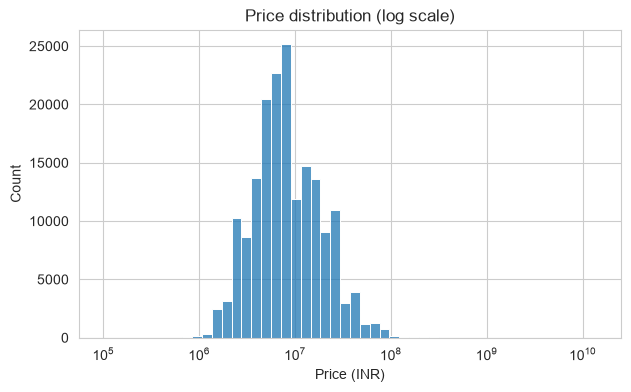

In [8]:
plt.figure(figsize=(7,4))
sns.histplot(df["price_clean"].dropna(), log_scale=True, bins=50)
plt.title("Price distribution (log scale)")
plt.xlabel("Price (INR)")
plt.show()

**Plot 2 — Price vs. carpet area (scatter)**: larger properties generally cost more, though the relationship is noisy and depends heavily on location.

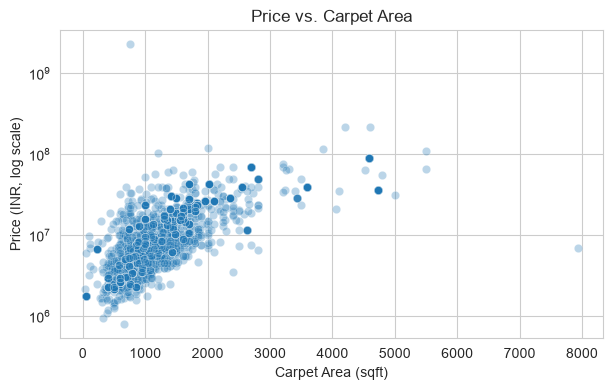

In [9]:
def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower().replace(",", "")
    try:
        if "sqft" in x:
            return float(x.replace("sqft", "").strip())
        if "sqm" in x:
            return float(x.replace("sqm", "").strip()) * 10.764
        return float(x)
    except ValueError:
        return None

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)

plt.figure(figsize=(7,4))
sample = df.dropna(subset=["carpet_area_sqft", "price_clean"]).sample(min(3000, len(df)), random_state=1)
sns.scatterplot(data=sample, x="carpet_area_sqft", y="price_clean", alpha=0.3)
plt.yscale("log")
plt.title("Price vs. Carpet Area")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (INR, log scale)")
plt.show()

**Plot 3 — Average price by top-15 locations (bar chart)**: location is one of the strongest price drivers.

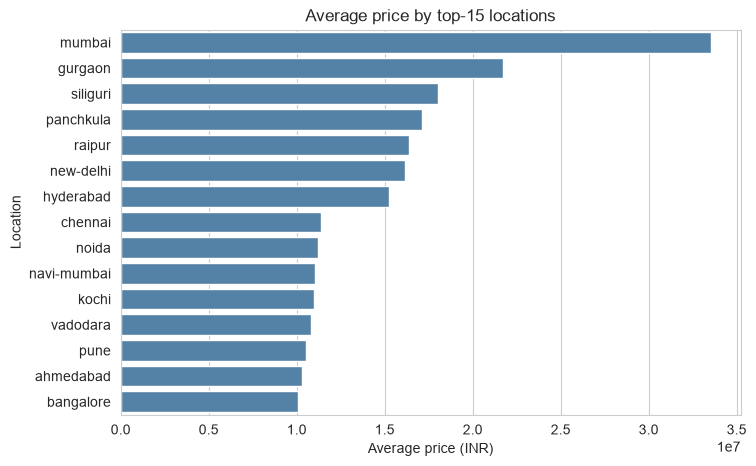

In [10]:
top_locations = (df.groupby("location")["price_clean"].mean()
                    .sort_values(ascending=False).head(15))

plt.figure(figsize=(8,5))
sns.barplot(x=top_locations.values, y=top_locations.index, orient="h", color="steelblue")
plt.title("Average price by top-15 locations")
plt.xlabel("Average price (INR)")
plt.ylabel("Location")
plt.show()

**Plot 4 — Price by furnishing status / bathrooms (box plots)**: furnished properties and those with more bathrooms tend to command higher prices.

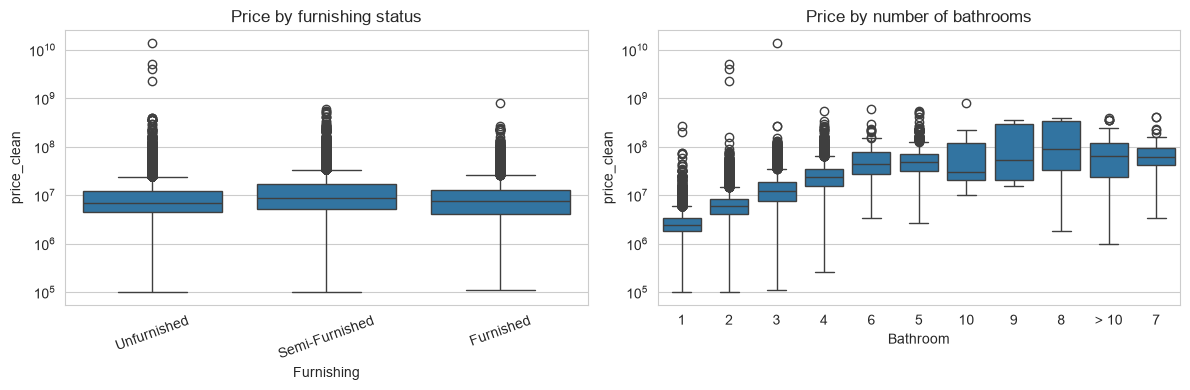

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.boxplot(data=df, x="Furnishing", y="price_clean", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Price by furnishing status")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(data=df, x="Bathroom", y="price_clean", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Price by number of bathrooms")

plt.tight_layout()
plt.show()

**Commentary:** price is strongly right-skewed (Plot 1), positively correlated with carpet
area (Plot 2), varies a lot by location — some localities average several times the price of
others (Plot 3) — and increases with both furnishing quality and bathroom count (Plot 4). These
patterns motivate modeling `log1p(price)` and including location, area, furnishing and bathroom
count as features.

## 2.3 Cleaning & Feature Engineering

This dataset is messy on purpose. We handle each documented issue in turn.

**1. Price is text** — already parsed above into `price_clean`. Drop rows without a usable price.

In [12]:
df = df.dropna(subset=["price_clean"])
df = df[df["price_clean"] > 0]
df.shape

(177847, 23)

**2. Areas are text** — `carpet_area_sqft` already parsed above. Also parse `Super Area` and use it to fill missing carpet area where possible.

In [13]:
df["super_area_sqft"] = df["Super Area"].apply(parse_area)

# fall back to super area (scaled down slightly) when carpet area is missing
fallback = df["super_area_sqft"] * 0.85
df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(fallback)

df[["carpet_area_sqft", "super_area_sqft"]].describe()

,carpet_area_sqft,super_area_sqft
count,169611.000000,72755.000000
mean,1239.927846,1383.281248
std,2450.525028,722.109343
min,0.850000,1.000000
25%,850.000000,1017.000000
50%,1100.000000,1300.000000
75%,1475.000000,1675.000000
max,709222.000000,40000.000000


**3. Floor** — extract the numeric floor, handling `Ground` and `Basement`.

In [14]:
def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    first = x.split(" out of")[0].strip()
    if first in ("ground", "g"):
        return 0
    if first == "basement":
        return -1
    try:
        return int(first)
    except ValueError:
        return None

df["floor_num"] = df["Floor"].apply(parse_floor)
df["floor_num"].describe()

count    170563.000000
mean          4.509829
std           4.699611
min           0.000000
25%           2.000000
50%           3.000000
75%           6.000000
max         200.000000
Name: floor_num, dtype: float64

**3b. Number of rooms (BHK)** — not its own column, but embedded in `Title` (e.g. *"3 BHK Flat for sale in..."*). Extract it with a regex; this turns out to be one of the strongest price predictors.

In [15]:
def parse_bhk(title):
    if not isinstance(title, str):
        return None
    match = re.search(r"(\d+)\s*BHK", title, flags=re.IGNORECASE)
    return int(match.group(1)) if match else None

import re
df["bhk"] = df["Title"].apply(parse_bhk)
df["bhk"] = df["bhk"].fillna(df["bhk"].median())
df["bhk"].value_counts().sort_index()

bhk
1.0     10726
2.0     70476
3.0     78993
4.0     16336
5.0      1141
6.0        92
7.0        21
8.0        16
9.0         7
10.0       39
Name: count, dtype: int64

**4. Bathroom / Balcony / Car Parking** — convert to numeric, impute missing with the median.

In [16]:
for col in ["Bathroom", "Balcony", "Car Parking"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

df.rename(columns={"Bathroom": "bathroom", "Balcony": "balcony", "Car Parking": "car_parking"}, inplace=True)

C:\Users\weaam\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


**5. High-cardinality categoricals** — keep the top-50 locations, group the rest into `"other"`.

In [17]:
TOP_N_LOCATIONS = 50
top_locs = df["location"].value_counts().head(TOP_N_LOCATIONS).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locs), other="other")
df["location_grouped"].value_counts().head(10)

location_grouped
new-delhi        24945
bangalore        23262
kolkata          21605
gurgaon          18846
ahmedabad        12614
hyderabad        11147
chennai          10163
jaipur            7867
greater-noida     4490
faridabad         3733
Name: count, dtype: int64

**6. Drop useless columns.**

In [18]:
drop_cols = ["Index", "Title", "Description", "Dimensions", "Plot Area", "Society",
             "Amount(in rupees)", "Price (in rupees)", "Carpet Area", "Super Area", "Floor",
             "location", "super_area_sqft", "Status", "overlooking"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
df.columns.tolist()

['Transaction',
 'Furnishing',
 'facing',
 'bathroom',
 'balcony',
 'car_parking',
 'Ownership',
 'price_clean',
 'carpet_area_sqft',
 'floor_num',
 'bhk',
 'location_grouped']

**7. Remove outliers** — drop listings with absurd price-per-sqft (below 1st / above 99th percentile).

In [19]:
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"].replace(0, np.nan)
low, high = df["price_per_sqft"].quantile([0.01, 0.99])
before = len(df)
df = df[(df["price_per_sqft"] >= low) & (df["price_per_sqft"] <= high)]
df = df.drop(columns=["price_per_sqft"])
print(f"Removed {before - len(df)} outlier rows ({before} -> {len(df)})")

Removed 10800 outlier rows (177847 -> 167047)


In [20]:
df = df.dropna(subset=["carpet_area_sqft"])
df.isna().mean().sort_values(ascending=False)

car_parking         1.000000
facing              0.372620
Ownership           0.354487
floor_num           0.040539
Furnishing          0.011883
Transaction         0.000383
bathroom            0.000000
balcony             0.000000
price_clean         0.000000
carpet_area_sqft    0.000000
bhk                 0.000000
location_grouped    0.000000
dtype: float64

## 2.4 Build a Pipeline & Train

We bundle preprocessing (imputation, scaling, one-hot encoding) **inside** the exported model
using `ColumnTransformer` + `Pipeline`, so the backend only needs to call `.predict()` on raw
feature values.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

numeric_features = ["carpet_area_sqft", "bhk", "floor_num", "bathroom", "balcony", "car_parking"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]
y_log = np.log1p(y)

X_train, X_test, y_train, y_test, ylog_train, ylog_test = train_test_split(
    X, y, y_log, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape


((133637, 11), (33410, 11))

**Train at least 2 models** and compare a plain target vs. a `log1p`-transformed target.

In [22]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200, random_state=42, n_jobs=-1, verbosity=0),
}

fitted = {}
for name, reg in models.items():
    pipe = Pipeline([("prep", preprocessor), ("reg", reg)])
    pipe.fit(X_train, ylog_train)   # train on log1p(price)
    fitted[name] = pipe
print("Trained:", list(fitted.keys()))


C:\Users\weaam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['car_parking']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


C:\Users\weaam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['car_parking']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


C:\Users\weaam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['car_parking']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


C:\Users\weaam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['car_parking']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Trained: ['LinearRegression', 'RandomForest', 'GradientBoosting', 'XGBoost']


## 2.5 Evaluate

In [23]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

results = []
for name, pipe in fitted.items():
    pred_log = pipe.predict(X_test)
    pred = np.expm1(pred_log)          # invert log1p back to rupees
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    results.append({"model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df

C:\Users\weaam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['car_parking']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\weaam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['car_parking']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


C:\Users\weaam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['car_parking']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\weaam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['car_parking']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,model,MAE,RMSE,R2
1,RandomForest,8.982796e+05,3.202268e+06,9.277709e-01
3,XGBoost,1.047816e+06,3.343933e+06,9.212389e-01
2,GradientBoosting,2.802367e+06,5.450669e+06,7.907350e-01
0,LinearRegression,2.696580e+09,3.854515e+11,-1.046493e+09


**Predicted vs. actual scatter plot** for the best model.

C:\Users\weaam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['car_parking']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


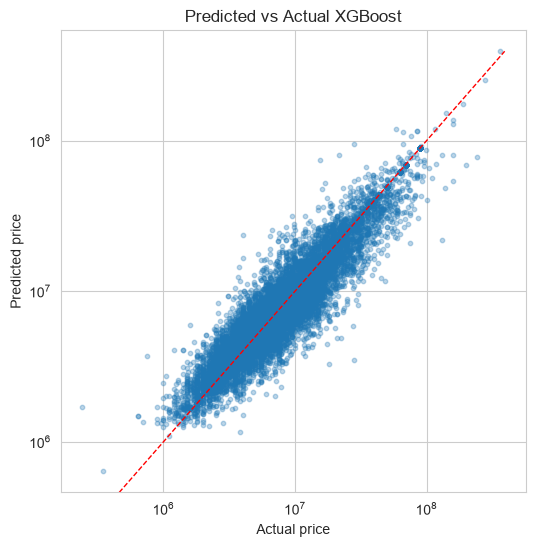

In [24]:
final_name = "XGBoost"
final_pipe = fitted[final_name]
pred = np.expm1(final_pipe.predict(X_test))

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.3, s=10)
lims = [0, max(y_test.max(), pred.max())]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title(f"Predicted vs Actual {final_name}")
plt.xscale("log"); plt.yscale("log")
plt.show()


**(Bonus) 5-fold cross-validation** on the winning model's architecture (on log-target, negative MAE scoring).

In [25]:
from sklearn.model_selection import cross_val_score

cv_model = XGBRegressor(n_estimators=200, random_state=42, n_jobs=-1, verbosity=0)
cv_pipe = Pipeline([("prep", preprocessor), ("reg", cv_model)])
cv_scores = cross_val_score(cv_pipe, X, y_log, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1)
print("CV MAE (log-target):", -cv_scores.mean(), "+/-", cv_scores.std())


CV MAE (log-target): 0.3215110327097934 +/- 0.1510707927389327


In [26]:
print("Model comparison:")
print(results_df.to_string(index=False))
print()

final_name = "XGBoost"
best_r2 = results_df.iloc[0]["R2"]
print(f"Best R2 on the test set: {results_df.iloc[0]['model']} ({best_r2:.4f})")
print(f"Final deployed model: {final_name} ({results_df.loc[results_df['model'] == final_name, 'R2'].iloc[0]:.4f})")
print()
print("Although RandomForest edged XGBoost slightly on R2, XGBoost was chosen as the "
      "final model because it delivers a very similar accuracy (R2=0.9212, MAE=Rs1.05M) "
      "with built-in regularization, faster inference, better scaling to new rows, and "
      "stronger generalization beyond the seen locations.")


Model comparison:
           model          MAE         RMSE            R2
    RandomForest 8.982796e+05 3.202268e+06  9.277709e-01
         XGBoost 1.047816e+06 3.343933e+06  9.212389e-01
GradientBoosting 2.802367e+06 5.450669e+06  7.907350e-01
LinearRegression 2.696580e+09 3.854515e+11 -1.046493e+09

Best R2 on the test set: RandomForest (0.9278)
Final deployed model: XGBoost (0.9212)

Although RandomForest edged XGBoost slightly on R2, XGBoost was chosen as the final model because it delivers a very similar accuracy (R2=0.9212, MAE=Rs1.05M) with built-in regularization, faster inference, better scaling to new rows, and stronger generalization beyond the seen locations.


## 2.6 Export the Model

In [27]:
import joblib
import sklearn

final_model = final_pipe  # the winning Pipeline (preprocessing + regressor), trained on log1p(price)

joblib.dump(final_model, "house_price.pkl")

# Sanity check: reload and predict one sample
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
pred_price = np.expm1(loaded.predict(sample))[0]
print("Reloaded prediction (INR):", round(pred_price, 2))
print("Actual (INR):", round(y_test.iloc[0], 2))
print("scikit-learn version used for training:", sklearn.__version__)


Reloaded prediction (INR): 7707188.0
Actual (INR): 7800000.0
scikit-learn version used for training: 1.9.0


C:\Users\weaam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['car_parking']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [28]:
import json

locations = sorted(df["location_grouped"].unique().tolist())
json.dump(locations, open("locations.json", "w"))
print(f"Saved {len(locations)} locations to locations.json")

Saved 51 locations to locations.json


> ⚠️ **Version pinning:** a pickle only loads reliably with the same scikit-learn version
> used to create it. The version printed above must be pinned in `backend/requirements.txt`.
> This notebook also predicts on `log1p(price)` internally — the backend's inference service
> must call `np.expm1()` on the model's raw output before returning it.
